<div style="background: #1a1a1a; padding: 30px; text-align: center; border-radius: 8px;">
    <div style="font-size: 32px; font-weight: bold; margin-bottom: 15px; background: linear-gradient(135deg, rgb(255, 183, 101) 0%, rgba(255, 215, 167, 0.97) 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">Mini-Project 2: Advanced Data Mining</div>
    <div style="font-size: 18px; font-weight: bold; margin-bottom: 3px; color: #ddd;">AE-1 — ECG Anomaly Detection with an Autoencoder</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Dataset:</strong> ECG5000 — heartbeat sequences of length 140</div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Task:</strong> train an Autoencoder only on normal heartbeats and detect anomalies using reconstruction error.</div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;"><strong>Primary metrics:</strong> Precision, Recall, F1-score.</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 12px; color: #ddd;"><strong>Hypothesis — Original Contribution</strong></div>
    <div style="background: rgba(255,255,255,0.05); border-left: 3px solid rgb(255, 183, 101); padding: 15px 20px; margin: 10px 0 8px 0; border-radius: 4px; text-align: left;">
        <div style="font-size: 15px; margin-bottom: 8px; color: #ddd; font-style: italic; line-height: 1.6;">"A validation-optimized reconstruction-error threshold will improve recall and F1 compared with a fixed 95th-percentile threshold calibrated on normal validation beats, with only a limited precision trade-off."</div>
        <div style="font-size: 13px; color: #aaa; line-height: 1.5;">The experiment is controlled: the Autoencoder and reconstruction errors are identical for both methods; only the threshold-selection rule changes.</div>
    </div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Professor: Dr. Hadi Farahani</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Head TA: Mr. Mobin Nesari</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;">Student: Alireza Jahanbakhsh</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 14px; color: #aaa;">Date: August 14, 2026 | Course: Data Mining</div>
</div>

# AE — ECG Anomaly Detection on ECG5000


## 1. Problem and Experimental Design


### 1.1 Research design
We train a compact Autoencoder only on normal ECG5000 heartbeats and use reconstruction error as the anomaly score. The original test split is never used for model fitting or threshold selection; it is reserved for final evaluation and post-hoc analysis.


### 1.2 Original contribution and hypothesis
We compare a fixed 95th-percentile threshold calibrated on normal validation errors with a validation-optimized threshold that maximizes F1 on the mixed labeled validation set. The Autoencoder and reconstruction scores stay unchanged, so the comparison isolates the threshold-selection rule while using the same validation partition. The optimized rule is supervised threshold calibration because it uses labeled validation anomalies.


In [1]:
import os, random, warnings, shutil
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, precision_recall_curve, auc,
                             average_precision_score)
from scipy import stats
from scipy.io import arff
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

ON_KAGGLE = os.path.isdir("/kaggle/working")
BASE_DIR = "/kaggle/working" if ON_KAGGLE else "."
INPUT_DIR = "/kaggle/input" if ON_KAGGLE else "."
FIG_DIR = os.path.join(BASE_DIR, "figures")
RES_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10})

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved:", path)

print("TensorFlow:", tf.__version__, "| On Kaggle:", ON_KAGGLE)

TensorFlow: 2.20.0 | On Kaggle: True


## 2. Data Loading and Preprocessing

The notebook accepts either the standard ECG5000 `.txt` files or Kaggle mirrors stored as `.arff`. The original test partition is preserved for final evaluation.


In [2]:
def parse_ecg(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".txt":
        arr = np.loadtxt(path)
        y = arr[:, 0].astype(int)
        X = arr[:, 1:].astype(np.float32)
        return y, X
    if ext == ".arff":
        data, _ = arff.loadarff(path)
        df = pd.DataFrame(data)
        labels = df.iloc[:, -1].to_numpy()
        y = np.array([int(float(v.decode() if isinstance(v, bytes) else v)) for v in labels])
        X = df.iloc[:, :-1].astype(np.float32).to_numpy()
        return y, X
    raise ValueError(f"Unsupported ECG5000 format: {ext}")

def find_split(split):
    names = [f"ECG5000_{split}.txt", f"ECG5000_{split}.arff"]
    for root, _, files in os.walk(INPUT_DIR):
        lookup = {f.lower(): f for f in files}
        for name in names:
            if name.lower() in lookup:
                return os.path.join(root, lookup[name.lower()])
    return None

train_file = find_split("TRAIN")
test_file = find_split("TEST")

if train_file is None or test_file is None:
    raise FileNotFoundError("ECG5000 TRAIN/TEST .txt or .arff files were not found. Add the ECG5000 dataset to Kaggle Input or place the files beside the notebook.")

y_train_raw, X_train_raw = parse_ecg(train_file)
y_test, X_test = parse_ecg(test_file)

assert X_train_raw.shape[1] == 140
assert X_test.shape[1] == 140

print("TRAIN:", train_file, X_train_raw.shape)
print("TEST :", test_file, X_test.shape)
print("Train labels:", dict(zip(*np.unique(y_train_raw, return_counts=True))))
print("Test labels :", dict(zip(*np.unique(y_test, return_counts=True))))

TRAIN: /kaggle/input/datasets/salsabilahmid/ecg50000/ECG5000_TRAIN.txt (500, 140)
TEST : /kaggle/input/datasets/salsabilahmid/ecg50000/ECG5000_TEST.txt (4500, 140)
Train labels: {np.int64(1): np.int64(292), np.int64(2): np.int64(177), np.int64(3): np.int64(10), np.int64(4): np.int64(19), np.int64(5): np.int64(2)}
Test labels : {np.int64(1): np.int64(2627), np.int64(2): np.int64(1590), np.int64(3): np.int64(86), np.int64(4): np.int64(175), np.int64(5): np.int64(22)}


### 2.1 Dataset overview

ECG5000 contains five original heartbeat classes:

- **Class 1:** normal
- **Classes 2–5:** abnormal

The original class labels are retained for later error analysis.


class 1: 2919 (normal)
class 2: 1767 (abnormal)
class 3: 96 (abnormal)
class 4: 194 (abnormal)
class 5: 24 (abnormal)
saved: /kaggle/working/figures/01_example_signals_per_class.png


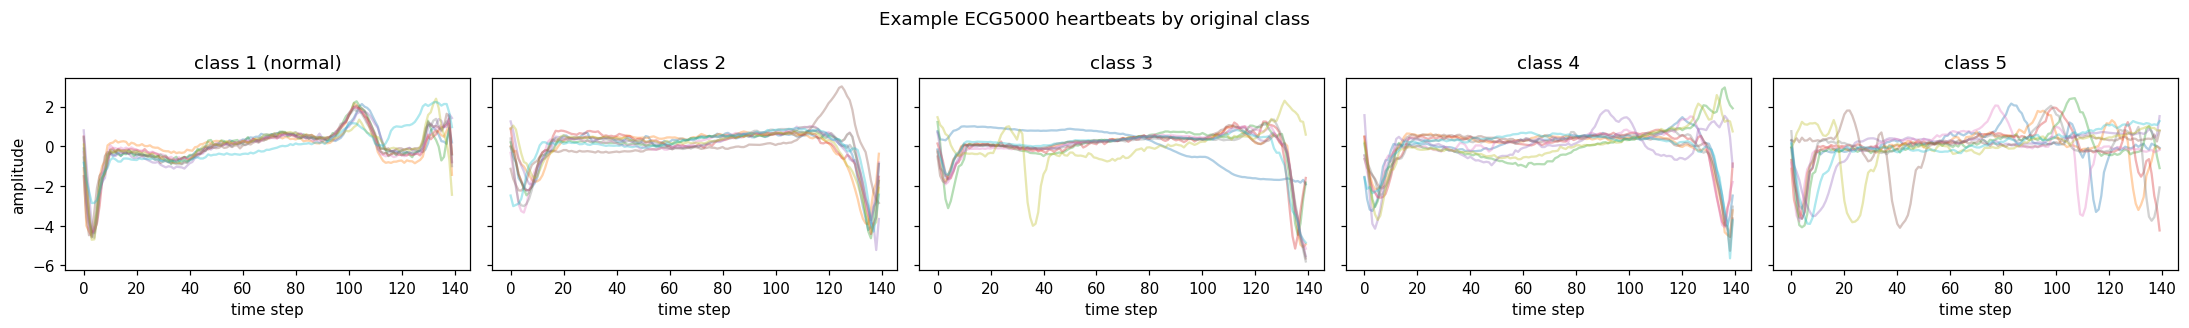

In [3]:
NORMAL_CLASS = 1



X_all = np.concatenate([X_train_raw, X_test])
y_all = np.concatenate([y_train_raw, y_test])



classes, counts = np.unique(y_all, return_counts=True)

for c, n in zip(classes, counts):
    tag = "normal" if c == NORMAL_CLASS else "abnormal"
    print(f"class {c}: {n} ({tag})")
y_bin_all = (y_all != NORMAL_CLASS).astype(int)



fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3), sharey=True)

for ax, c in zip(np.atleast_1d(axes), classes):
    idx = np.where(y_all == c)[0][:10]
    for i in idx:
        ax.plot(X_all[i], alpha=0.35)
    ax.set_title(f"class {c}" + (" (normal)" if c == NORMAL_CLASS else ""))
    ax.set_xlabel("time step")



np.atleast_1d(axes)[0].set_ylabel("amplitude")
fig.suptitle("Example ECG5000 heartbeats by original class")

fig.tight_layout()
save_fig(fig, "01_example_signals_per_class.png")
plt.show()

### 2.2 Train/validation split and train-only scaling

Only the original TRAIN partition is divided into training and validation subsets.

- The Autoencoder is fitted only on normal training samples.
- Normal validation samples are used for early stopping.
- Normal validation errors define the fixed-percentile baseline.
- The mixed labeled validation set is used only for the optimized threshold.
- Per-timestep standardization is fitted only on normal training samples.


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.30,
    stratify=y_train_raw,
    random_state=SEED
)

yb_train = (y_train != NORMAL_CLASS).astype(int)
yb_val = (y_val != NORMAL_CLASS).astype(int)
yb_test = (y_test != NORMAL_CLASS).astype(int)

scaler = StandardScaler()
scaler.fit(X_train[yb_train == 0])

Xs_train = scaler.transform(X_train).astype(np.float32)
Xs_val = scaler.transform(X_val).astype(np.float32)
Xs_test = scaler.transform(X_test).astype(np.float32)

Xs_train_norm = Xs_train[yb_train == 0]
Xs_val_norm = Xs_val[yb_val == 0]

for name, yb in [("train", yb_train), ("validation", yb_val), ("test", yb_test)]:
    print(
        f"{name:10s}: {len(yb):4d} | "
        f"normal {(yb == 0).sum():4d} | abnormal {(yb == 1).sum():4d}"
    )

print("AE training samples:", Xs_train_norm.shape)
print("Scaler fitted on normal-train only:", scaler.mean_.shape)

train     :  350 | normal  204 | abnormal  146
validation:  150 | normal   88 | abnormal   62
test      : 4500 | normal 2627 | abnormal 1873
AE training samples: (204, 140)
Scaler fitted on normal-train only: (140,)


## 3. Autoencoder Baseline


### 3.1 Architecture
A compact dense Autoencoder uses the structure $140 \to 64 \to 32 \to 8 \to 32 \to 64 \to 140$ with ReLU hidden activations and a linear reconstruction output.


In [5]:
def build_autoencoder(bottleneck=8, seq_len=140):
    inp = keras.Input(shape=(seq_len,))
    x = layers.Dense(64, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(bottleneck, activation="relu", name="bottleneck")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(seq_len, activation="linear")(x)
    model = keras.Model(inp, out, name=f"dense_ae_b{bottleneck}")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

    return model



ae = build_autoencoder(bottleneck=8)

ae.summary()

I0000 00:00:1786794086.998810      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786794087.001521      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "dense_ae_b8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 140)            │         9,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,868 (89.33 KB)

 Trainable params: 22,868 (89.33 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Common training protocol

The Autoencoder is trained only on normal training heartbeats with MSE loss and Adam. Early stopping monitors reconstruction loss on normal validation samples and restores the best weights. If training reaches the epoch limit, the notebook reports that directly rather than implying early stopping was triggered.


2026-08-15 11:41:28.555706: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


trained for 200 epochs | best epoch = 199 | reached epoch limit
best val_loss = 0.220505
saved: /kaggle/working/figures/02_training_curves.png


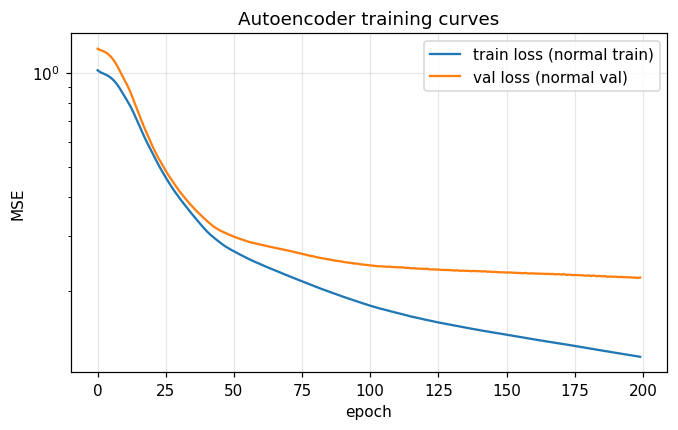

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=0)

history = ae.fit(
    Xs_train_norm, Xs_train_norm,
    validation_data=(Xs_val_norm, Xs_val_norm),
    epochs=200, batch_size=128, shuffle=True,
    callbacks=[early_stop], verbose=0)

n_epochs = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
status = "early-stopped" if n_epochs < 200 else "reached epoch limit"

print(f"trained for {n_epochs} epochs | best epoch = {best_epoch} | {status}")
print(f"best val_loss = {min(history.history['val_loss']):.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history["loss"], label="train loss (normal train)")
ax.plot(history.history["val_loss"], label="val loss (normal val)")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_title("Autoencoder training curves")
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, "02_training_curves.png")
plt.show()

## 4. Baseline Evaluation

### 4.1 Reconstruction-error distributions and fixed threshold

Per-sample reconstruction MSE is used as the anomaly score. The fixed baseline flags a heartbeat as abnormal when its error exceeds the 95th percentile of **normal validation** reconstruction errors. This keeps threshold calibration separate from the samples used to fit the Autoencoder.


2026-08-15 11:41:55.190536: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


baseline threshold (95th pct of normal-validation errors): 0.700382
split     group    n     mean      std   median      p95
train    normal  204 0.123287 0.106555 0.095015 0.272145
train anomalous  146 2.023267 1.147852 1.838156 3.052513
  val    normal   88 0.220505 0.264224 0.146775 0.700382
  val anomalous   62 1.890766 0.493034 1.840096 2.896752
 test    normal 2627 0.229973 0.493890 0.128479 0.602138
 test anomalous 1873 2.041810 1.708453 1.825507 2.916133
saved: /kaggle/working/figures/03_error_distributions.png


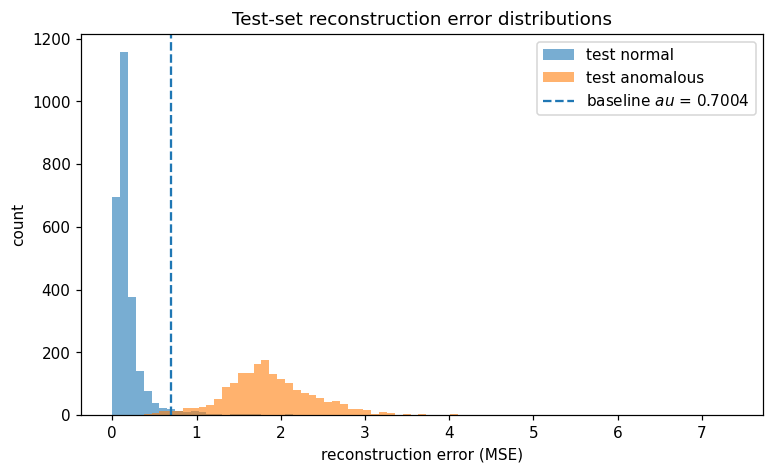

In [7]:
def recon_errors(model, A):
    R = model.predict(A, verbose=0)
    return np.mean((A - R) ** 2, axis=1)

err_train = recon_errors(ae, Xs_train)
err_val = recon_errors(ae, Xs_val)
err_test = recon_errors(ae, Xs_test)

tau_baseline = np.percentile(err_val[yb_val == 0], 95)
print(f"baseline threshold (95th pct of normal-validation errors): {tau_baseline:.6f}")

rows = []
for split, err, yb in [("train", err_train, yb_train),
                       ("val", err_val, yb_val),
                       ("test", err_test, yb_test)]:
    for grp, mask in [("normal", yb == 0), ("anomalous", yb == 1)]:
        e = err[mask]
        rows.append({"split": split, "group": grp, "n": int(mask.sum()),
                     "mean": e.mean(), "std": e.std(), "median": np.median(e),
                     "p95": np.percentile(e, 95)})

err_summary = pd.DataFrame(rows)
err_summary.to_csv(os.path.join(RES_DIR, "reconstruction_error_summary.csv"), index=False)
print(err_summary.round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, np.percentile(err_test, 99.5), 80)
ax.hist(err_test[yb_test == 0], bins=bins, alpha=0.6, label="test normal")
ax.hist(err_test[yb_test == 1], bins=bins, alpha=0.6, label="test anomalous")
ax.axvline(tau_baseline, ls="--", label=f"baseline $\tau$ = {tau_baseline:.4f}")
ax.set_xlabel("reconstruction error (MSE)")
ax.set_ylabel("count")
ax.set_title("Test-set reconstruction error distributions")
ax.legend()
save_fig(fig, "03_error_distributions.png")
plt.show()

## 5. Original Contribution: Validation-Optimized Threshold

### 5.1 Method

Threshold candidates come directly from the validation precision-recall curve. The selected threshold maximizes validation F1. The same validation partition is used for both threshold rules, while only the optimized rule uses anomaly labels. The test set is not used during threshold selection.


validation-optimized threshold: 1.350430 (val F1 = 0.9756)
baseline threshold           : 0.700382 (val F1 = 0.9531)
saved: /kaggle/working/figures/04_threshold_sweep.png


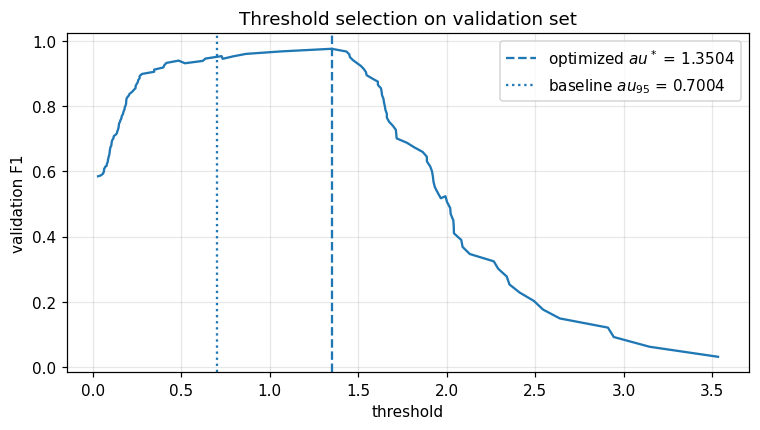

In [8]:
val_prec, val_rec, val_thresholds = precision_recall_curve(yb_val, err_val)
val_f1 = 2 * val_prec[:-1] * val_rec[:-1] / (val_prec[:-1] + val_rec[:-1] + 1e-12)
best_idx = int(np.nanargmax(val_f1))
tau_opt = val_thresholds[best_idx]

base_val_f1 = f1_score(yb_val, (err_val > tau_baseline).astype(int), zero_division=0)

print(f"validation-optimized threshold: {tau_opt:.6f} (val F1 = {val_f1[best_idx]:.4f})")
print(f"baseline threshold           : {tau_baseline:.6f} (val F1 = {base_val_f1:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(val_thresholds, val_f1)
ax.axvline(tau_opt, ls="--", label=f"optimized $\tau^*$ = {tau_opt:.4f}")
ax.axvline(tau_baseline, ls=":", label=f"baseline $\tau_{{95}}$ = {tau_baseline:.4f}")
ax.set_xlabel("threshold")
ax.set_ylabel("validation F1")
ax.set_title("Threshold selection on validation set")
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, "04_threshold_sweep.png")
plt.show()

### 5.2 Test-set ablation

The fixed-percentile and validation-optimized thresholds are applied to the same final test reconstruction errors. Precision, Recall, and F1 are the primary operating-point metrics. Average Precision and PR-AUC are also reported for the common reconstruction-error ranking.


                  method  threshold  precision  recall     f1  accuracy
baseline_95th_percentile     0.7004     0.9439  0.9797 0.9615    0.9673
    validation_optimized     1.3504     0.9742  0.8655 0.9166    0.9344

Score metrics:
 average_precision  pr_auc
            0.9515  0.9514
saved: /kaggle/working/figures/05_confusion_matrices.png


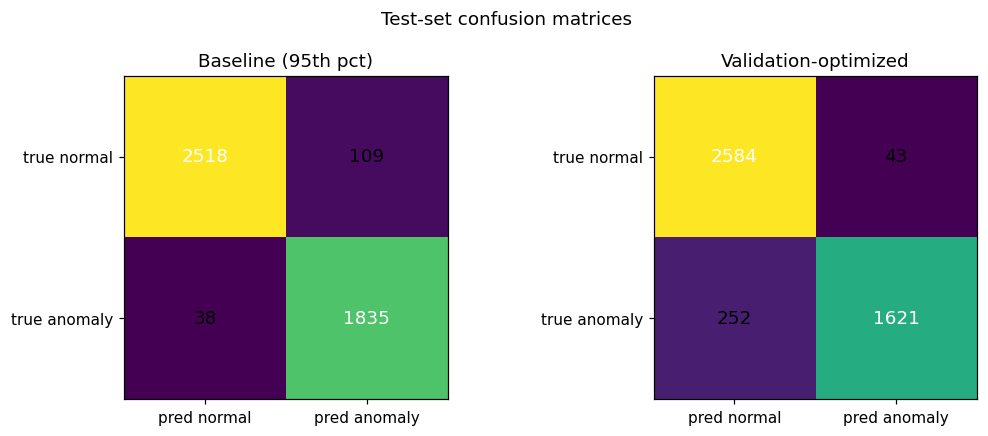

saved: /kaggle/working/figures/06_metric_comparison.png


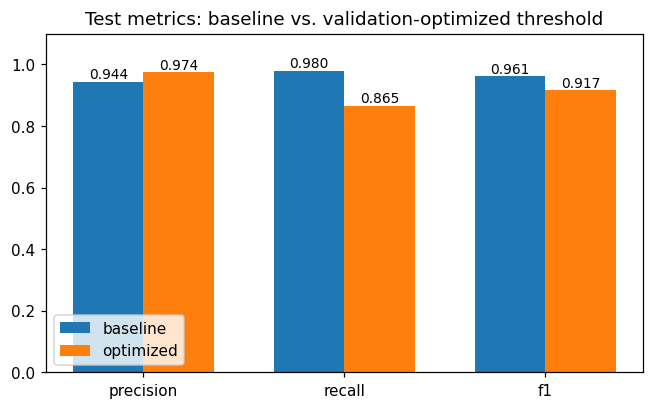

saved: /kaggle/working/figures/07_pr_curve.png


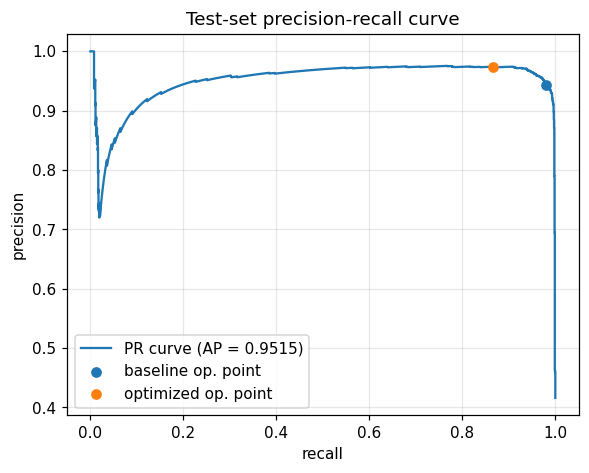

In [9]:
def evaluate(y_true, err, tau, method):
    pred = (err > tau).astype(int)
    return {
        "method": method,
        "threshold": tau,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "accuracy": accuracy_score(y_true, pred)
    }, pred

res_base, pred_base = evaluate(yb_test, err_test, tau_baseline, "baseline_95th_percentile")
res_opt, pred_opt = evaluate(yb_test, err_test, tau_opt, "validation_optimized")

comparison = pd.DataFrame([res_base, res_opt])
comparison.to_csv(os.path.join(RES_DIR, "threshold_comparison.csv"), index=False)
comparison.to_csv(os.path.join(RES_DIR, "final_metrics.csv"), index=False)
print(comparison.round(4).to_string(index=False))

prec_curve, rec_curve, _ = precision_recall_curve(yb_test, err_test)
pr_auc = auc(rec_curve, prec_curve)
avg_precision = average_precision_score(yb_test, err_test)
score_metrics = pd.DataFrame([{
    "average_precision": avg_precision,
    "pr_auc": pr_auc
}])
score_metrics.to_csv(os.path.join(RES_DIR, "score_metrics.csv"), index=False)
print("\nScore metrics:")
print(score_metrics.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, ttl in [(axes[0], pred_base, "Baseline (95th pct)"),
                      (axes[1], pred_opt, "Validation-optimized")]:
    cm = confusion_matrix(yb_test, pred)
    ax.imshow(cm)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred normal", "pred anomaly"])
    ax.set_yticklabels(["true normal", "true anomaly"])
    ax.set_title(ttl)
fig.suptitle("Test-set confusion matrices")
fig.tight_layout()
save_fig(fig, "05_confusion_matrices.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
metrics = ["precision", "recall", "f1"]
xpos = np.arange(len(metrics))
w = 0.35
ax.bar(xpos - w / 2, [res_base[m] for m in metrics], w, label="baseline")
ax.bar(xpos + w / 2, [res_opt[m] for m in metrics], w, label="optimized")
for i, m in enumerate(metrics):
    ax.text(i - w / 2, res_base[m] + 0.01, f"{res_base[m]:.3f}", ha="center", fontsize=9)
    ax.text(i + w / 2, res_opt[m] + 0.01, f"{res_opt[m]:.3f}", ha="center", fontsize=9)
ax.set_xticks(xpos)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title("Test metrics: baseline vs. validation-optimized threshold")
ax.legend()
save_fig(fig, "06_metric_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(rec_curve, prec_curve, label=f"PR curve (AP = {avg_precision:.4f})")
ax.scatter([res_base["recall"]], [res_base["precision"]], zorder=5, label="baseline op. point")
ax.scatter([res_opt["recall"]], [res_opt["precision"]], zorder=5, label="optimized op. point")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Test-set precision-recall curve")
ax.legend()
ax.grid(alpha=0.3)
save_fig(fig, "07_pr_curve.png")
plt.show()

In [10]:
delta_f1 = res_opt["f1"] - res_base["f1"]
delta_recall = res_opt["recall"] - res_base["recall"]
delta_precision = res_opt["precision"] - res_base["precision"]

effect = pd.DataFrame([{
    "delta_f1": delta_f1,
    "delta_recall": delta_recall,
    "delta_precision": delta_precision
}])
effect.to_csv(os.path.join(RES_DIR, "threshold_effect.csv"), index=False)

print(f"F1 change       : {delta_f1:+.4f}")
print(f"Recall change   : {delta_recall:+.4f}")
print(f"Precision change: {delta_precision:+.4f}")

if delta_f1 > 0 and delta_recall > 0:
    print("Interpretation: directionally supports the hypothesis; effect size should be judged with uncertainty below.")
else:
    print("Interpretation: the expected F1/recall improvement was not consistently observed.")

F1 change       : -0.0449
Recall change   : -0.1143
Precision change: +0.0302
Interpretation: the expected F1/recall improvement was not consistently observed.


## 6. Statistical Analysis

### 6.1 Reconstruction-error separation

A one-sided Mann–Whitney U test checks whether abnormal test heartbeats tend to have larger reconstruction errors than normal test heartbeats. This evaluates score separation, not superiority of one threshold rule over the other.


In [11]:
e_norm = err_test[yb_test == 0]
e_anom = err_test[yb_test == 1]

U, p = stats.mannwhitneyu(e_anom, e_norm, alternative="greater")
cles = U / (len(e_anom) * len(e_norm))

mw = pd.DataFrame([{
    "U_statistic": U,
    "p_value": p,
    "alternative": "abnormal errors > normal errors",
    "n_normal": len(e_norm),
    "n_abnormal": len(e_anom),
    "median_normal": np.median(e_norm),
    "median_abnormal": np.median(e_anom),
    "CLES_P(abnormal>normal)": cles
}])

mw.to_csv(os.path.join(RES_DIR, "mannwhitney_test.csv"), index=False)
print(mw.drop(columns=["p_value"]).round(6).to_string(index=False))
print("p-value:", f"{p:.3e}" if p > 0 else "below floating-point resolution")

if p < 0.05:
    print("Result: abnormal reconstruction errors are significantly larger than normal errors.")
else:
    print("Result: the data do not provide significant evidence of larger abnormal reconstruction errors.")

 U_statistic                     alternative  n_normal  n_abnormal  median_normal  median_abnormal  CLES_P(abnormal>normal)
   4852239.0 abnormal errors > normal errors      2627        1873       0.128479         1.825507                 0.986153
p-value: below floating-point resolution
Result: abnormal reconstruction errors are significantly larger than normal errors.


### 6.2 Paired bootstrap uncertainty for the threshold contribution

Because both threshold rules are evaluated on the same test heartbeats, paired bootstrap resampling is used to estimate 95% confidence intervals for the changes in Precision, Recall, and F1. This directly quantifies uncertainty around the primary contribution.


In [12]:
rng = np.random.default_rng(SEED)
B = 2000
boot = []
n = len(yb_test)

for _ in range(B):
    idx = rng.integers(0, n, n)
    yt = yb_test[idx]
    pb = pred_base[idx]
    po = pred_opt[idx]
    if len(np.unique(yt)) < 2:
        continue
    boot.append({
        "delta_precision": precision_score(yt, po, zero_division=0) - precision_score(yt, pb, zero_division=0),
        "delta_recall": recall_score(yt, po, zero_division=0) - recall_score(yt, pb, zero_division=0),
        "delta_f1": f1_score(yt, po, zero_division=0) - f1_score(yt, pb, zero_division=0)
    })

boot_df = pd.DataFrame(boot)
ci_rows = []
for metric in ["delta_precision", "delta_recall", "delta_f1"]:
    lo, hi = np.percentile(boot_df[metric], [2.5, 97.5])
    ci_rows.append({
        "metric": metric,
        "observed": effect.iloc[0][metric],
        "ci_2.5%": lo,
        "ci_97.5%": hi
    })

bootstrap_ci = pd.DataFrame(ci_rows)
bootstrap_ci.to_csv(os.path.join(RES_DIR, "threshold_bootstrap_ci.csv"), index=False)
print(bootstrap_ci.round(4).to_string(index=False))

         metric  observed  ci_2.5%  ci_97.5%
delta_precision    0.0302   0.0227    0.0384
   delta_recall   -0.1143  -0.1289   -0.0996
       delta_f1   -0.0449  -0.0539   -0.0359


## 7. Error Analysis

False positives and false negatives under the validation-optimized threshold are analyzed by original ECG5000 class. Failure plots use cases near the median error within each failure group rather than only the most extreme examples.


False positives: 43
False negatives: 252

Per-class anomaly miss rates:
 class  test_count  false_negatives  miss_rate
     2        1590              153     0.0962
     3          86               15     0.1744
     4         175               76     0.4343
     5          22                8     0.3636


2026-08-15 11:42:19.738501: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


saved: /kaggle/working/figures/08_failure_cases.png


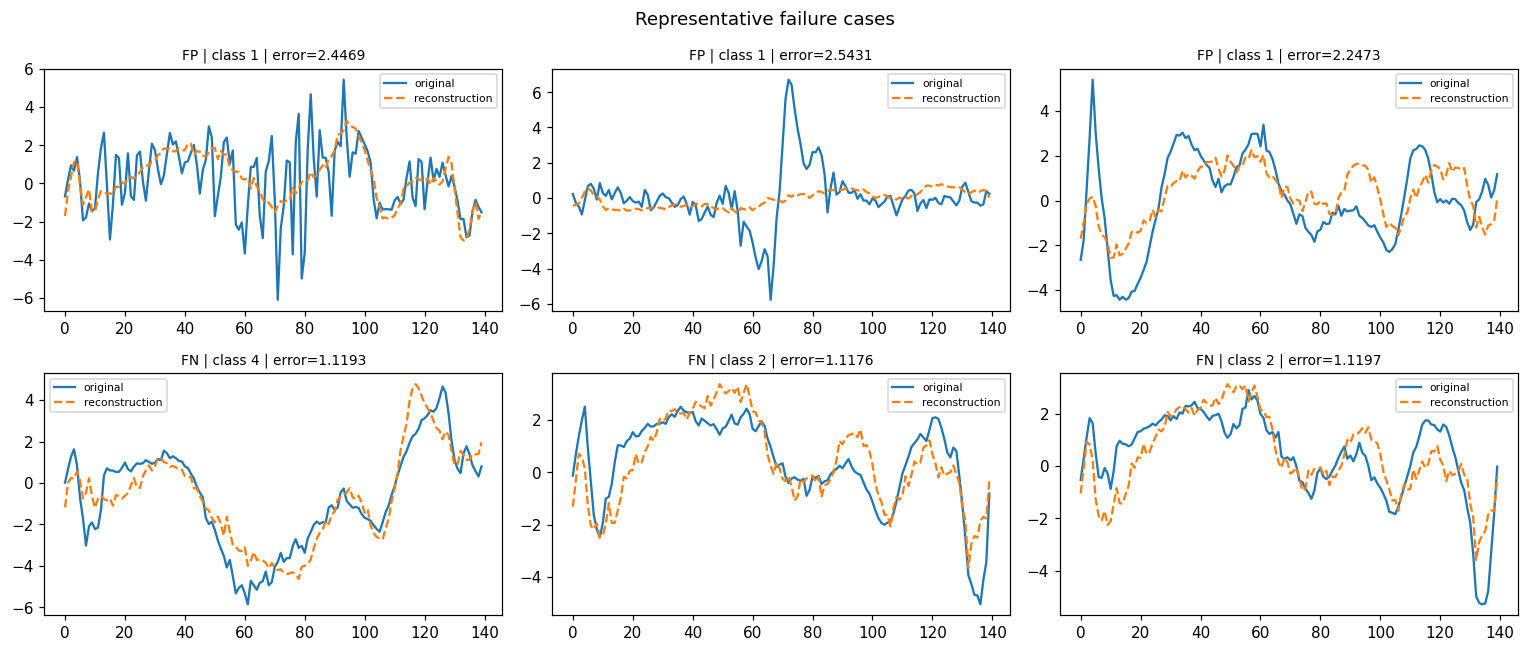

In [13]:
fp_idx_all = np.where((yb_test == 0) & (pred_opt == 1))[0]
fn_idx_all = np.where((yb_test == 1) & (pred_opt == 0))[0]

def median_examples(indices, errors, k=3):
    if len(indices) == 0:
        return np.array([], dtype=int)
    med = np.median(errors[indices])
    order = np.argsort(np.abs(errors[indices] - med))
    return indices[order[:k]]

fp_idx = median_examples(fp_idx_all, err_test)
fn_idx = median_examples(fn_idx_all, err_test)

print("False positives:", len(fp_idx_all))
print("False negatives:", len(fn_idx_all))

miss_rows = []
for c in sorted(np.unique(y_test[y_test != NORMAL_CLASS])):
    total = int(np.sum(y_test == c))
    missed = int(np.sum(y_test[fn_idx_all] == c))
    miss_rows.append({
        "class": int(c),
        "test_count": total,
        "false_negatives": missed,
        "miss_rate": missed / total if total else np.nan
    })

miss_table = pd.DataFrame(miss_rows)
miss_table.to_csv(os.path.join(RES_DIR, "per_class_miss_rates.csv"), index=False)
print("\nPer-class anomaly miss rates:")
print(miss_table.round(4).to_string(index=False))

recon_test = ae.predict(Xs_test, verbose=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for row, (idxs, kind) in enumerate([(fp_idx, "FP"), (fn_idx, "FN")]):
    for k in range(3):
        ax = axes[row, k]
        if k < len(idxs):
            i = idxs[k]
            ax.plot(Xs_test[i], label="original")
            ax.plot(recon_test[i], ls="--", label="reconstruction")
            ax.set_title(f"{kind} | class {y_test[i]} | error={err_test[i]:.4f}", fontsize=9)
            ax.legend(fontsize=7)
        else:
            ax.axis("off")
fig.suptitle("Representative failure cases")
fig.tight_layout()
save_fig(fig, "08_failure_cases.png")
plt.show()

## 8. Supplementary Experiments for the Required Discussion Questions

### 8.1 Bottleneck-capacity experiment

This experiment is not the primary original contribution. Bottleneck sizes 2, 8, and 32 are compared under the same protocol to examine whether additional Autoencoder capacity changes normal-vs-abnormal reconstruction-error separation. Results are interpreted cautiously: a wider bottleneck supports the reconstruction-paradox argument only if separation degrades, not merely because capacity increased.


2026-08-15 11:42:46.519560: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


bottleneck  2 done: test F1 = 0.9604


2026-08-15 11:43:12.239501: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


bottleneck  8 done: test F1 = 0.9166


2026-08-15 11:43:38.054858: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


bottleneck 32 done: test F1 = 0.9579

 bottleneck  normal_test_err_mean  anomalous_test_err_mean  error_contrast_ratio  precision  recall     f1
          2                0.4057                   4.5155               11.1294     0.9685  0.9525 0.9604
          8                0.2300                   2.0418                8.8785     0.9742  0.8655 0.9166
         32                0.1881                   1.3577                7.2171     0.9323  0.9851 0.9579
saved: /kaggle/working/figures/09_bottleneck_comparison.png


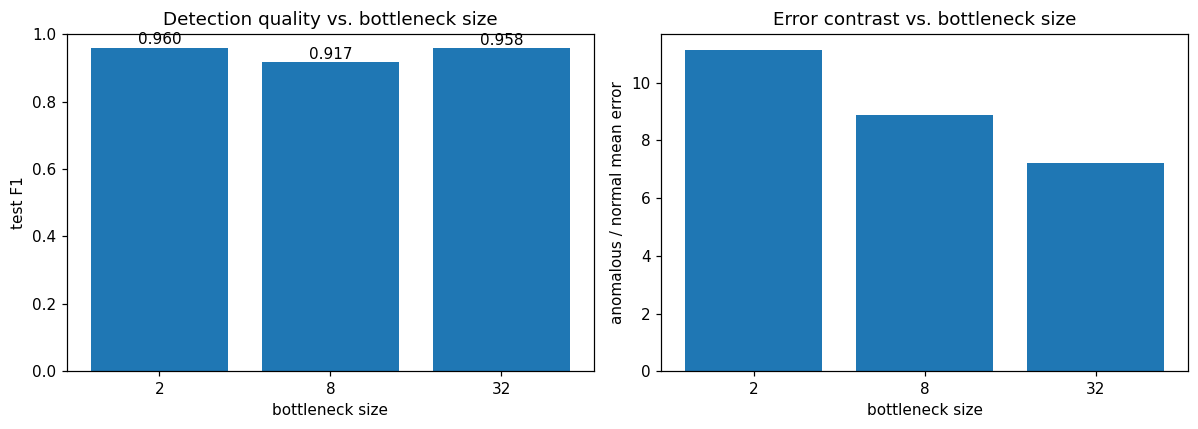

Highest error contrast: bottleneck 2
Highest test F1       : bottleneck 2
A wider bottleneck is evidence of the reconstruction paradox only if anomaly/normal separation degrades consistently.


In [14]:
bottleneck_rows = []

for b in [2, 8, 32]:
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    m = build_autoencoder(bottleneck=b)
    m.fit(
        Xs_train_norm, Xs_train_norm,
        validation_data=(Xs_val_norm, Xs_val_norm),
        epochs=200, batch_size=128, shuffle=True,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)],
        verbose=0
    )

    ev = recon_errors(m, Xs_val)
    et = recon_errors(m, Xs_test)
    vp, vr, vt = precision_recall_curve(yb_val, ev)
    vf1 = 2 * vp[:-1] * vr[:-1] / (vp[:-1] + vr[:-1] + 1e-12)
    tau_b = vt[int(np.nanargmax(vf1))]
    pred_b = (et > tau_b).astype(int)

    bottleneck_rows.append({
        "bottleneck": b,
        "normal_test_err_mean": et[yb_test == 0].mean(),
        "anomalous_test_err_mean": et[yb_test == 1].mean(),
        "error_contrast_ratio": et[yb_test == 1].mean() / et[yb_test == 0].mean(),
        "precision": precision_score(yb_test, pred_b, zero_division=0),
        "recall": recall_score(yb_test, pred_b, zero_division=0),
        "f1": f1_score(yb_test, pred_b, zero_division=0)
    })
    print(f"bottleneck {b:2d} done: test F1 = {bottleneck_rows[-1]['f1']:.4f}")

bn = pd.DataFrame(bottleneck_rows)
bn.to_csv(os.path.join(RES_DIR, "bottleneck_comparison.csv"), index=False)
print()
print(bn.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([str(b) for b in bn["bottleneck"]], bn["f1"])
axes[0].set_xlabel("bottleneck size")
axes[0].set_ylabel("test F1")
axes[0].set_title("Detection quality vs. bottleneck size")
axes[0].set_ylim(0, 1)
for i, v in enumerate(bn["f1"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")
axes[1].bar([str(b) for b in bn["bottleneck"]], bn["error_contrast_ratio"])
axes[1].set_xlabel("bottleneck size")
axes[1].set_ylabel("anomalous / normal mean error")
axes[1].set_title("Error contrast vs. bottleneck size")
fig.tight_layout()
save_fig(fig, "09_bottleneck_comparison.png")
plt.show()

best_contrast_b = int(bn.loc[bn["error_contrast_ratio"].idxmax(), "bottleneck"])
best_f1_b = int(bn.loc[bn["f1"].idxmax(), "bottleneck"])
print(f"Highest error contrast: bottleneck {best_contrast_b}")
print(f"Highest test F1       : bottleneck {best_f1_b}")
print("A wider bottleneck is evidence of the reconstruction paradox only if anomaly/normal separation degrades consistently.")

### 8.2 Temporal reconstruction-error profile

The temporal error profile is a post-hoc analysis of the final test set. It shows where normal and abnormal reconstruction behavior differs most along the heartbeat and provides project-specific context for the self-attention experiment. These regions are not attention weights and are not used to redesign or retune the model.


saved: /kaggle/working/figures/10_temporal_error_profile.png


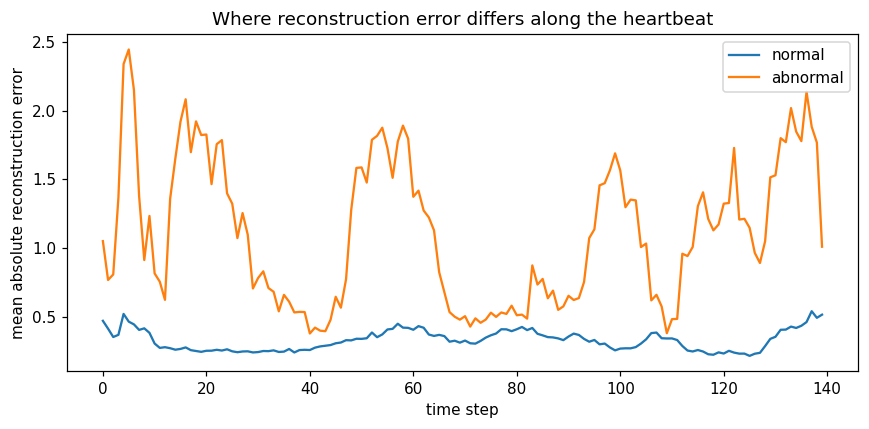

Largest abnormal-vs-normal error gaps at time steps:
[5, 4, 16, 6, 136, 18, 15, 133]


In [15]:
abs_error = np.abs(Xs_test - recon_test)



normal_profile = abs_error[yb_test == 0].mean(axis=0)
abnormal_profile = abs_error[yb_test == 1].mean(axis=0)
gap_profile = abnormal_profile - normal_profile
top_steps = np.argsort(gap_profile)[-8:][::-1]



fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(normal_profile, label="normal")
ax.plot(abnormal_profile, label="abnormal")
ax.set_xlabel("time step")
ax.set_ylabel("mean absolute reconstruction error")
ax.set_title("Where reconstruction error differs along the heartbeat")
ax.legend()
fig.tight_layout()
save_fig(fig, "10_temporal_error_profile.png")
plt.show()



print("Largest abnormal-vs-normal error gaps at time steps:")
print(top_steps.tolist())

### 8.3 Controlled self-attention ablation

To answer the second discussion question experimentally, two sequence Autoencoders are trained on the same normal-only training data under the same optimization protocol. They share the same convolutional reconstruction backbone; the only architectural difference is whether a self-attention block is inserted between the encoder and decoder. Each model selects its anomaly threshold on the validation set, then Precision, Recall, F1, reconstruction-error separation, and parameter count are compared on the untouched test set.

For the attention model, the learned attention scores are also extracted directly. Averaging over test samples, heads, and query positions gives a temporal key-importance profile showing which heartbeat positions the trained attention block tends to revisit. This profile is interpreted together with the no-attention ablation because visually concentrated attention alone does not establish a detection benefit.


2026-08-15 11:44:05.364365: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-08-15 11:44:36.478077: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

         model  threshold  precision  recall     f1  normal_test_err_mean  anomalous_test_err_mean  error_contrast_ratio  parameters  epochs_ran
  no_attention     0.0021     0.7726  0.8398 0.8048                0.0017                   0.0038                2.2669        5345         200
self_attention     0.0140     0.9030  0.9744 0.9373                0.0117                   0.1131                9.6741        9633         200
saved: /kaggle/working/figures/11_self_attention_ablation.png


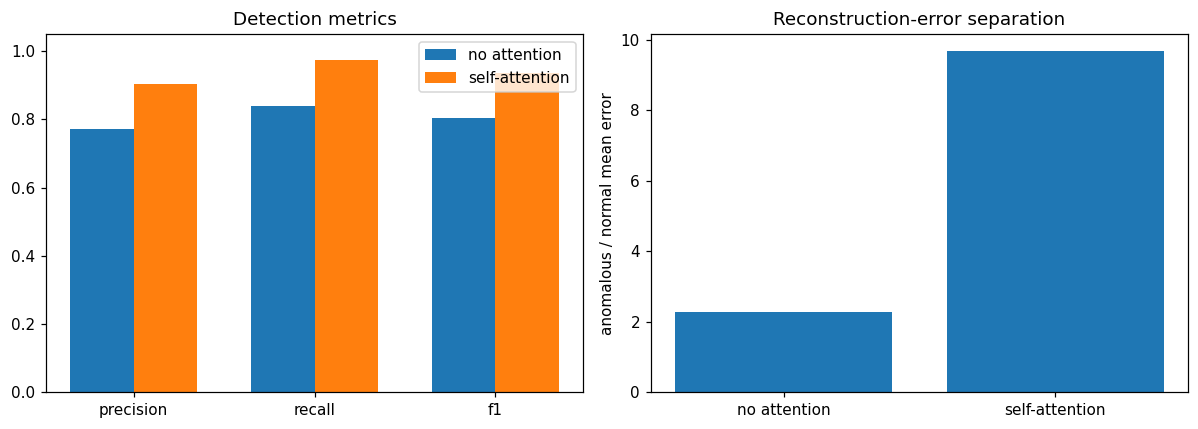

saved: /kaggle/working/figures/12_self_attention_profile.png


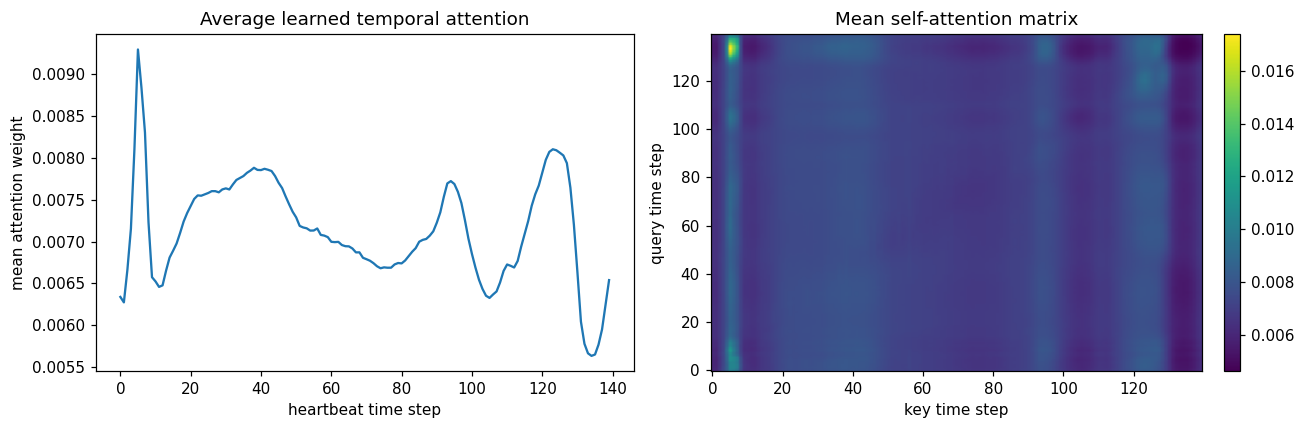

Highest average attention key positions:
[5, 6, 7, 4, 123, 124, 122, 125, 126, 121]
Self-attention minus no-attention F1: +0.1325
Self-attention minus no-attention recall: +0.1345
Self-attention minus no-attention error-contrast ratio: +7.4072


In [16]:
def build_sequence_autoencoder(use_attention=False, seq_len=140):
    inp = keras.Input(shape=(seq_len, 1))
    x = layers.Conv1D(16, 5, padding="same", activation="relu")(inp)
    x = layers.Conv1D(32, 5, padding="same", activation="relu")(x)

    score_model = None
    if use_attention:
        attn_layer = layers.MultiHeadAttention(num_heads=2, key_dim=16, name="self_attention")
        attn_out, attn_scores = attn_layer(x, x, return_attention_scores=True)
        x = layers.LayerNormalization()(x + attn_out)
        score_model = keras.Model(inp, attn_scores, name="attention_score_model")

    x = layers.Conv1D(16, 5, padding="same", activation="relu")(x)
    out = layers.Conv1D(1, 5, padding="same", activation="linear")(x)
    model = keras.Model(inp, out, name="sequence_ae_attention" if use_attention else "sequence_ae_no_attention")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model, score_model

def sequence_recon_errors(model, A):
    A3 = A[..., None]
    R = model.predict(A3, verbose=0)
    return np.mean((A3 - R) ** 2, axis=(1, 2))

attention_rows = []
attention_models = {}

for use_attention, label in [(False, "no_attention"), (True, "self_attention")]:
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model, score_model = build_sequence_autoencoder(use_attention=use_attention)

    history_attn = model.fit(
        Xs_train_norm[..., None], Xs_train_norm[..., None],
        validation_data=(Xs_val_norm[..., None], Xs_val_norm[..., None]),
        epochs=200,
        batch_size=128,
        shuffle=True,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)],
        verbose=0
    )

    ev = sequence_recon_errors(model, Xs_val)
    et = sequence_recon_errors(model, Xs_test)

    vp, vr, vt = precision_recall_curve(yb_val, ev)
    vf1 = 2 * vp[:-1] * vr[:-1] / (vp[:-1] + vr[:-1] + 1e-12)
    tau = vt[int(np.nanargmax(vf1))]
    pred = (et > tau).astype(int)

    normal_mean = float(et[yb_test == 0].mean())
    anomaly_mean = float(et[yb_test == 1].mean())

    attention_rows.append({
        "model": label,
        "threshold": tau,
        "precision": precision_score(yb_test, pred, zero_division=0),
        "recall": recall_score(yb_test, pred, zero_division=0),
        "f1": f1_score(yb_test, pred, zero_division=0),
        "normal_test_err_mean": normal_mean,
        "anomalous_test_err_mean": anomaly_mean,
        "error_contrast_ratio": anomaly_mean / normal_mean,
        "parameters": model.count_params(),
        "epochs_ran": len(history_attn.history["loss"])
    })

    attention_models[label] = (model, score_model)

attention_ablation = pd.DataFrame(attention_rows)
attention_ablation.to_csv(os.path.join(RES_DIR, "self_attention_ablation.csv"), index=False)
print(attention_ablation.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics = ["precision", "recall", "f1"]
x = np.arange(len(metrics))
w = 0.35
row_no = attention_ablation[attention_ablation["model"] == "no_attention"].iloc[0]
row_attn = attention_ablation[attention_ablation["model"] == "self_attention"].iloc[0]
axes[0].bar(x - w / 2, [row_no[m] for m in metrics], w, label="no attention")
axes[0].bar(x + w / 2, [row_attn[m] for m in metrics], w, label="self-attention")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Detection metrics")
axes[0].legend()
axes[1].bar(["no attention", "self-attention"], [row_no["error_contrast_ratio"], row_attn["error_contrast_ratio"]])
axes[1].set_ylabel("anomalous / normal mean error")
axes[1].set_title("Reconstruction-error separation")
fig.tight_layout()
save_fig(fig, "11_self_attention_ablation.png")
plt.show()

attention_model, attention_score_model = attention_models["self_attention"]
attention_scores = attention_score_model.predict(Xs_test[..., None], batch_size=128, verbose=0)
mean_attention_matrix = attention_scores.mean(axis=(0, 1))
key_importance = mean_attention_matrix.mean(axis=0)
top_attention_steps = np.argsort(key_importance)[-10:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(len(key_importance)), key_importance)
axes[0].set_xlabel("heartbeat time step")
axes[0].set_ylabel("mean attention weight")
axes[0].set_title("Average learned temporal attention")
im = axes[1].imshow(mean_attention_matrix, aspect="auto", origin="lower")
axes[1].set_xlabel("key time step")
axes[1].set_ylabel("query time step")
axes[1].set_title("Mean self-attention matrix")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
save_fig(fig, "12_self_attention_profile.png")
plt.show()

print("Highest average attention key positions:")
print(top_attention_steps.tolist())

delta_attn_f1 = float(row_attn["f1"] - row_no["f1"])
delta_attn_recall = float(row_attn["recall"] - row_no["recall"])
delta_attn_contrast = float(row_attn["error_contrast_ratio"] - row_no["error_contrast_ratio"])
print(f"Self-attention minus no-attention F1: {delta_attn_f1:+.4f}")
print(f"Self-attention minus no-attention recall: {delta_attn_recall:+.4f}")
print(f"Self-attention minus no-attention error-contrast ratio: {delta_attn_contrast:+.4f}")


### 8.4 Multi-seed robustness

The primary threshold comparison is repeated across five model-initialization seeds while keeping the data split fixed. This checks whether a small threshold advantage is robust to Autoencoder training randomness rather than an artifact of a single initialization.


In [17]:
seed_rows = []

for seed in [7, 21, 42, 77, 123]:
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    m = build_autoencoder(bottleneck=8)
    m.fit(
        Xs_train_norm, Xs_train_norm,
        validation_data=(Xs_val_norm, Xs_val_norm),
        epochs=200, batch_size=128, shuffle=True,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)],
        verbose=0
    )

    ev = recon_errors(m, Xs_val)
    et = recon_errors(m, Xs_test)
    tb = np.percentile(ev[yb_val == 0], 95)
    vp, vr, vt = precision_recall_curve(yb_val, ev)
    vf1 = 2 * vp[:-1] * vr[:-1] / (vp[:-1] + vr[:-1] + 1e-12)
    to = vt[int(np.nanargmax(vf1))]
    rb, _ = evaluate(yb_test, et, tb, "baseline")
    ro, _ = evaluate(yb_test, et, to, "optimized")

    seed_rows.append({
        "seed": seed,
        "baseline_precision": rb["precision"],
        "baseline_recall": rb["recall"],
        "baseline_f1": rb["f1"],
        "optimized_precision": ro["precision"],
        "optimized_recall": ro["recall"],
        "optimized_f1": ro["f1"],
        "delta_precision": ro["precision"] - rb["precision"],
        "delta_recall": ro["recall"] - rb["recall"],
        "delta_f1": ro["f1"] - rb["f1"]
    })
    print(f"seed {seed:3d}: delta F1 = {seed_rows[-1]['delta_f1']:+.4f}")

seed_results = pd.DataFrame(seed_rows)
seed_results.to_csv(os.path.join(RES_DIR, "multi_seed_threshold_results.csv"), index=False)
print("\nPer-seed results:")
print(seed_results.round(4).to_string(index=False))

seed_summary = seed_results[["delta_precision", "delta_recall", "delta_f1"]].agg(["mean", "std"]).T.reset_index()
seed_summary.columns = ["metric", "mean", "std"]
seed_summary.to_csv(os.path.join(RES_DIR, "multi_seed_summary.csv"), index=False)
print("\nDelta mean ± std:")
for _, r in seed_summary.iterrows():
    print(f"{r['metric']:16s}: {r['mean']:+.4f} ± {r['std']:.4f}")

2026-08-15 11:44:42.138270: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-15 11:45:05.556630: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

seed   7: delta F1 = -0.0328


2026-08-15 11:45:31.508535: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


seed  21: delta F1 = +0.0189


2026-08-15 11:45:57.555292: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


seed  42: delta F1 = -0.0449


2026-08-15 11:46:23.623328: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


seed  77: delta F1 = -0.0103


2026-08-15 11:46:49.530390: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


seed 123: delta F1 = -0.0215

Per-seed results:
 seed  baseline_precision  baseline_recall  baseline_f1  optimized_precision  optimized_recall  optimized_f1  delta_precision  delta_recall  delta_f1
    7              0.9487           0.9770       0.9627               0.9759            0.8879        0.9298           0.0273       -0.0892   -0.0328
   21              0.9506           0.9247       0.9375               0.9256            0.9893        0.9564          -0.0250        0.0646    0.0189
   42              0.9439           0.9797       0.9615               0.9742            0.8655        0.9166           0.0302       -0.1143   -0.0449
   77              0.9429           0.9883       0.9651               0.9576            0.9519        0.9548           0.0146       -0.0363   -0.0103
  123              0.9455           0.9818       0.9633               0.9601            0.9242        0.9418           0.0146       -0.0577   -0.0215

Delta mean ± std:
delta_precision : +0.0123 ± 0.022

### 8.5 Stretch bonus — Isolation Forest baseline

As a lightweight bonus baseline, Isolation Forest is fitted only on normal training heartbeats. Its anomaly score is calibrated with the 95th percentile of normal validation scores, matching the one-class thresholding protocol of the fixed Autoencoder baseline.


In [18]:
iso = IsolationForest(n_estimators=300, contamination="auto", random_state=SEED, n_jobs=-1)
iso.fit(Xs_train_norm)

iso_val_score = -iso.score_samples(Xs_val)
iso_test_score = -iso.score_samples(Xs_test)
tau_iso = np.percentile(iso_val_score[yb_val == 0], 95)
res_iso, pred_iso = evaluate(yb_test, iso_test_score, tau_iso, "isolation_forest")

bonus_comparison = pd.DataFrame([res_base, res_opt, res_iso])
bonus_comparison.to_csv(os.path.join(RES_DIR, "bonus_isolation_forest_comparison.csv"), index=False)
print(bonus_comparison.round(4).to_string(index=False))

iso_ap = average_precision_score(yb_test, iso_test_score)
print(f"Isolation Forest Average Precision: {iso_ap:.4f}")

                  method  threshold  precision  recall     f1  accuracy
baseline_95th_percentile     0.7004     0.9439  0.9797 0.9615    0.9673
    validation_optimized     1.3504     0.9742  0.8655 0.9166    0.9344
        isolation_forest     0.5889     0.7246  0.1335 0.2254    0.6182
Isolation Forest Average Precision: 0.8274


## 9. Discussion & Observation — Required Questions

### 9.1 Question 1 — The reconstruction paradox

Reconstruction-based anomaly detection needs a persistent gap between normal and abnormal reconstruction errors. If the Autoencoder becomes too expressive, it can learn a near-identity mapping and reconstruct abnormal beats well, shrinking that gap. The bottleneck experiment therefore examines both F1 and the abnormal-to-normal error contrast rather than assuming that more capacity is automatically harmful. A deliberate sensitivity-preserving design would use a compact bottleneck, fewer hidden units or layers, regularization or denoising, early stopping, and training restricted to representative normal beats. The correct conclusion depends on the measured separation: if a wider model does not reduce separation, this experiment does not establish the paradox.

### 9.2 Question 2 — What does self-attention reveal, and does it help?

The controlled ablation in Section 8.3 shows that self-attention was genuinely useful in this experiment rather than merely adding capacity. The no-attention Autoencoder achieved a test F1 of approximately 0.805, whereas the self-attention model reached approximately 0.937. Recall increased from about 0.840 to 0.974 and precision increased from about 0.770 to 0.903.

The reconstruction-error separation also became substantially stronger. The anomalous-to-normal mean reconstruction-error ratio increased from approximately 2.27 without attention to 9.67 with self-attention. Therefore, the additional attention block did not simply increase model size; it produced a substantially more discriminative reconstruction pattern for anomaly detection under the same training protocol.

The learned attention weights provide further insight into what the model uses as part of the heartbeat representation. The highest average attention was concentrated around early time steps 4–7 and later positions around 121–126. This suggests that the model repeatedly uses information from these temporal regions when reconstructing the heartbeat and that they may contribute strongly to the learned normal signature. The full attention matrix also shows that the mechanism is not restricted to purely local interactions, allowing information from distant parts of the heartbeat to influence each other.

These attention weights should not be interpreted as causal explanations by themselves. However, because the attention visualization is accompanied by a controlled no-attention ablation with clear improvements in F1, recall, precision, and reconstruction-error separation, the results provide evidence that self-attention genuinely helped anomaly detection in this setup rather than only adding extra capacity.


## 10. Limitations

ECG5000 is a single pre-segmented dataset and the original TRAIN partition is small. The validation-optimized threshold is supervised because it requires labeled validation anomalies and may overfit a small validation set. The dense Autoencoder does not explicitly encode local temporal structure. Multi-seed evaluation reduces, but does not eliminate, training-variance concerns. The bottleneck study changes one capacity dimension rather than every aspect of model complexity. Test-set temporal and failure analyses are post-hoc and are not used for retuning.


## 11. Reproducibility, Sources, and Outputs

The notebook uses fixed seeds, deterministic TensorFlow operations when available, automatic `.txt`/`.arff` ECG5000 loading, and train-only preprocessing. Figures are saved to `figures/`, result tables to `results/`, and the trained Autoencoder is saved for reuse. The final cell also writes pinned dependencies and a short README.

**Sources**

- ECG5000 dataset: UCR/UEA Time Series Classification Archive, `timeseriesclassification.com`.
- TensorFlow / Keras: `tensorflow.org` and `keras.io`.
- Isolation Forest baseline: scikit-learn `IsolationForest` implementation.


In [19]:
ae.save(os.path.join(BASE_DIR, "ecg_autoencoder.keras"))

packages = ["numpy", "pandas", "matplotlib", "scikit-learn", "scipy", "tensorflow"]
requirements = []
for package in packages:
    try:
        requirements.append(f"{package}=={metadata.version(package)}")
    except metadata.PackageNotFoundError:
        pass

with open(os.path.join(BASE_DIR, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(requirements) + "\n")

readme = f"""# ECG5000 Autoencoder Anomaly Detection

Run the notebook from top to bottom.

Dataset: ECG5000 TRAIN and TEST files in either .txt or .arff format.
On Kaggle, attach an ECG5000 dataset under Kaggle Input.
The loader searches recursively for ECG5000_TRAIN and ECG5000_TEST.

Primary experiment: fixed 95th-percentile normal-validation threshold vs. labeled validation-F1 optimized threshold.
Bonus baseline: Isolation Forest trained only on normal training beats.

Random seed: {SEED}
"""

with open(os.path.join(BASE_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme)

print("FIGURES:")
for f in sorted(os.listdir(FIG_DIR)):
    print(os.path.join(FIG_DIR, f))

print("\nRESULTS:")
for f in sorted(os.listdir(RES_DIR)):
    print(os.path.join(RES_DIR, f))

print("\nMODEL:")
print(os.path.join(BASE_DIR, "ecg_autoencoder.keras"))
print("\nREPRODUCIBILITY:")
print(os.path.join(BASE_DIR, "README.md"))
print(os.path.join(BASE_DIR, "requirements.txt"))

FIGURES:
/kaggle/working/figures/01_example_signals_per_class.png
/kaggle/working/figures/02_training_curves.png
/kaggle/working/figures/03_error_distributions.png
/kaggle/working/figures/04_threshold_sweep.png
/kaggle/working/figures/05_confusion_matrices.png
/kaggle/working/figures/06_metric_comparison.png
/kaggle/working/figures/07_pr_curve.png
/kaggle/working/figures/08_failure_cases.png
/kaggle/working/figures/09_bottleneck_comparison.png
/kaggle/working/figures/10_temporal_error_profile.png
/kaggle/working/figures/11_self_attention_ablation.png
/kaggle/working/figures/12_self_attention_profile.png

RESULTS:
/kaggle/working/results/bonus_isolation_forest_comparison.csv
/kaggle/working/results/bottleneck_comparison.csv
/kaggle/working/results/final_metrics.csv
/kaggle/working/results/mannwhitney_test.csv
/kaggle/working/results/multi_seed_summary.csv
/kaggle/working/results/multi_seed_threshold_results.csv
/kaggle/working/results/per_class_miss_rates.csv
/kaggle/working/results/rec

In [20]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "ecg_project_figures"),
    "zip",
    FIG_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/ecg_project_figures.zip


In [21]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "ecg_project_results"),
    "zip",
    RES_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/ecg_project_results.zip
